# MODULE 3 — ML Classique Spatial
## Cours Magistral Interactif — Prédire les phases IPC au Burkina Faso

> **Cours** : Analyse Spatiale avec Machine Learning (ASML)  
> **Institut** : 2iE — Master Eau, Environnement, Aménagement  

## Objectifs d'apprentissage

| # | Objectif | Section |
|---|---------|---------|
| OA1 | Random Forest — principe, hyperparamètres, imbalance | §2 |
| OA2 | Gradient Boosting / XGBoost — différences avec RF | §3 |
| OA3 | Spatial Cross-Validation — éviter le data leakage | §4 |
| OA4 | Métriques adaptées : Kappa, F1-macro, Moran I résidus | §5 |
| OA5 | Feature importance et SHAP | §6 |
| OA6 | Carte prédictive des phases IPC | §7 |

> Les **exercices** sont dans `M3_TP_Enonce.ipynb` — sur une variable cible différente.

In [1]:
!pip install scikit-learn xgboost shap imbalanced-learn geopandas libpysal esda folium --quiet

In [2]:
import json, warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, cohen_kappa_score,
                             f1_score, mean_absolute_error)
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier

from libpysal.weights import Queen, KNN
from libpysal.weights import lag_spatial
from esda.moran import Moran
import folium

print('Bibliothèques chargées.')

# ── Feature matrix M2 embarquée ──
FM_JSON = '[{"province":"Oudalan","region":"Sahel","superficie_km2":22236,"compacite":0.42,"pop_density":14.5,"fapar_mean":0.05,"fapar_trend":-0.006,"ipc_lag":3.6,"dist_route_km":245,"travel_time_mean_h":4.2,"ipc_phase":4,"lat":14.48,"lon":-0.48},{"province":"Séno","region":"Sahel","superficie_km2":13484,"compacite":0.55,"pop_density":24.1,"fapar_mean":0.06,"fapar_trend":-0.005,"ipc_lag":3.5,"dist_route_km":198,"travel_time_mean_h":3.8,"ipc_phase":4,"lat":14.1,"lon":-0.1},{"province":"Soum","region":"Sahel","superficie_km2":15704,"compacite":0.48,"pop_density":23.5,"fapar_mean":0.07,"fapar_trend":-0.004,"ipc_lag":3.7,"dist_route_km":220,"travel_time_mean_h":4.0,"ipc_phase":4,"lat":13.98,"lon":-1.55},{"province":"Yagha","region":"Sahel","superficie_km2":12376,"compacite":0.62,"pop_density":17.3,"fapar_mean":0.09,"fapar_trend":-0.003,"ipc_lag":3.2,"dist_route_km":185,"travel_time_mean_h":3.5,"ipc_phase":3,"lat":13.35,"lon":0.75},{"province":"Loroum","region":"Nord","superficie_km2":5549,"compacite":0.71,"pop_density":35.0,"fapar_mean":0.11,"fapar_trend":-0.002,"ipc_lag":3.0,"dist_route_km":120,"travel_time_mean_h":2.8,"ipc_phase":3,"lat":13.7,"lon":-2.1},{"province":"Yatenga","region":"Nord","superficie_km2":7275,"compacite":0.68,"pop_density":73.5,"fapar_mean":0.13,"fapar_trend":-0.001,"ipc_lag":2.9,"dist_route_km":85,"travel_time_mean_h":2.2,"ipc_phase":3,"lat":13.55,"lon":-2.35},{"province":"Passoré","region":"Nord","superficie_km2":3957,"compacite":0.74,"pop_density":79.1,"fapar_mean":0.15,"fapar_trend":0.0,"ipc_lag":2.8,"dist_route_km":65,"travel_time_mean_h":1.9,"ipc_phase":3,"lat":12.89,"lon":-2.2},{"province":"Sanmatenga","region":"Centre-Nord","superficie_km2":8860,"compacite":0.65,"pop_density":60.0,"fapar_mean":0.16,"fapar_trend":0.001,"ipc_lag":2.7,"dist_route_km":72,"travel_time_mean_h":1.8,"ipc_phase":3,"lat":13.05,"lon":-1.2},{"province":"Namentenga","region":"Centre-Nord","superficie_km2":6670,"compacite":0.58,"pop_density":49.6,"fapar_mean":0.18,"fapar_trend":0.001,"ipc_lag":2.5,"dist_route_km":95,"travel_time_mean_h":2.1,"ipc_phase":3,"lat":13.1,"lon":-0.5},{"province":"Bam","region":"Centre-Nord","superficie_km2":5869,"compacite":0.72,"pop_density":50.3,"fapar_mean":0.19,"fapar_trend":0.002,"ipc_lag":2.3,"dist_route_km":80,"travel_time_mean_h":1.7,"ipc_phase":2,"lat":13.45,"lon":-1.4},{"province":"Kadiogo","region":"Centre","superficie_km2":2585,"compacite":0.81,"pop_density":934.3,"fapar_mean":0.25,"fapar_trend":0.003,"ipc_lag":2.1,"dist_route_km":12,"travel_time_mean_h":0.4,"ipc_phase":2,"lat":12.36,"lon":-1.53},{"province":"Bazega","region":"Centre-Sud","superficie_km2":3706,"compacite":0.76,"pop_density":61.0,"fapar_mean":0.28,"fapar_trend":0.002,"ipc_lag":2.0,"dist_route_km":45,"travel_time_mean_h":1.1,"ipc_phase":2,"lat":12.1,"lon":-1.4},{"province":"Zoundweogo","region":"Centre-Sud","superficie_km2":2590,"compacite":0.79,"pop_density":94.2,"fapar_mean":0.27,"fapar_trend":0.002,"ipc_lag":2.1,"dist_route_km":55,"travel_time_mean_h":1.3,"ipc_phase":2,"lat":11.85,"lon":-0.85},{"province":"Nahouri","region":"Centre-Sud","superficie_km2":3918,"compacite":0.66,"pop_density":47.2,"fapar_mean":0.26,"fapar_trend":0.001,"ipc_lag":2.0,"dist_route_km":70,"travel_time_mean_h":1.6,"ipc_phase":2,"lat":11.5,"lon":-1.1},{"province":"Boulgou","region":"Centre-Est","superficie_km2":5868,"compacite":0.59,"pop_density":67.8,"fapar_mean":0.22,"fapar_trend":0.002,"ipc_lag":2.4,"dist_route_km":110,"travel_time_mean_h":2.3,"ipc_phase":3,"lat":11.85,"lon":-0.2},{"province":"Ganzourgou","region":"Plateau Central","superficie_km2":5226,"compacite":0.67,"pop_density":48.8,"fapar_mean":0.21,"fapar_trend":0.002,"ipc_lag":2.2,"dist_route_km":58,"travel_time_mean_h":1.4,"ipc_phase":2,"lat":12.35,"lon":-0.75},{"province":"Houet","region":"Hauts-Bassins","superficie_km2":10200,"compacite":0.61,"pop_density":99.5,"fapar_mean":0.38,"fapar_trend":0.004,"ipc_lag":1.8,"dist_route_km":22,"travel_time_mean_h":0.7,"ipc_phase":2,"lat":11.18,"lon":-4.3},{"province":"Comoé","region":"Cascades","superficie_km2":16000,"compacite":0.55,"pop_density":17.1,"fapar_mean":0.44,"fapar_trend":0.005,"ipc_lag":1.5,"dist_route_km":85,"travel_time_mean_h":1.8,"ipc_phase":1,"lat":10.6,"lon":-4.65},{"province":"Poni","region":"Sud-Ouest","superficie_km2":10075,"compacite":0.52,"pop_density":26.5,"fapar_mean":0.48,"fapar_trend":0.005,"ipc_lag":1.6,"dist_route_km":95,"travel_time_mean_h":2.0,"ipc_phase":2,"lat":10.3,"lon":-3.3},{"province":"Noumbiel","region":"Sud-Ouest","superficie_km2":3562,"compacite":0.63,"pop_density":28.1,"fapar_mean":0.52,"fapar_trend":0.006,"ipc_lag":1.5,"dist_route_km":120,"travel_time_mean_h":2.4,"ipc_phase":2,"lat":10.0,"lon":-3.1}]'

df = pd.read_json(FM_JSON)
FEATURES = ['superficie_km2','compacite','pop_density',
            'fapar_mean','fapar_trend','ipc_lag',
            'dist_route_km','travel_time_mean_h']
TARGET = 'ipc_phase'

X = df[FEATURES].values
y = df[TARGET].astype(int).values
print(f'Feature matrix : {X.shape[0]} provinces x {X.shape[1]} features')
print(f'Distribution IPC : {dict(zip(*np.unique(y,return_counts=True)))}')

Bibliothèques chargées.
Feature matrix : 20 provinces x 8 features
Distribution IPC : {np.int64(1): np.int64(1), np.int64(2): np.int64(9), np.int64(3): np.int64(7), np.int64(4): np.int64(3)}


/tmp/ipykernel_1204/1019740190.py:27: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_json(FM_JSON)


---
# §2 — Random Forest : Principe et Application

> 🎯 **OA1** — Random Forest, hyperparamètres, gestion du déséquilibre des classes

## 2.1 Construction et entraînement

Le Random Forest construit B arbres indépendants sur des sous-ensembles
aléatoires des données (bootstrap) et des features (feature bagging).
La prédiction finale est le **vote majoritaire** des B arbres.

In [3]:
# Construction du Random Forest IPC
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,           # Limiter le surapprentissage sur 45 observations
    min_samples_leaf=2,
    class_weight='balanced',  # Compenser les phases rares (IPC 4, 5)
    random_state=42, n_jobs=-1
)
rf.fit(X, y)

y_pred_train = rf.predict(X)
kappa_train  = cohen_kappa_score(y, y_pred_train)
print(f'Kappa (entraînement) : {kappa_train:.3f}')
print('⚠️ Ce score est biaisé — entraîné ET évalué sur les mêmes données')
print('→ La spatial CV (§4) donnera le score honnête.')

Kappa (entraînement) : 1.000
⚠️ Ce score est biaisé — entraîné ET évalué sur les mêmes données
→ La spatial CV (§4) donnera le score honnête.


## 2.2 Distribution des phases IPC et class_weight

> ⚠️ **class_weight='balanced'** est indispensable quand les classes sont déséquilibrées.
> Sans cela, le modèle prédit toujours la classe majoritaire (IPC 2–3)
> et ignore complètement les phases 4 et 5 — les plus critiques.

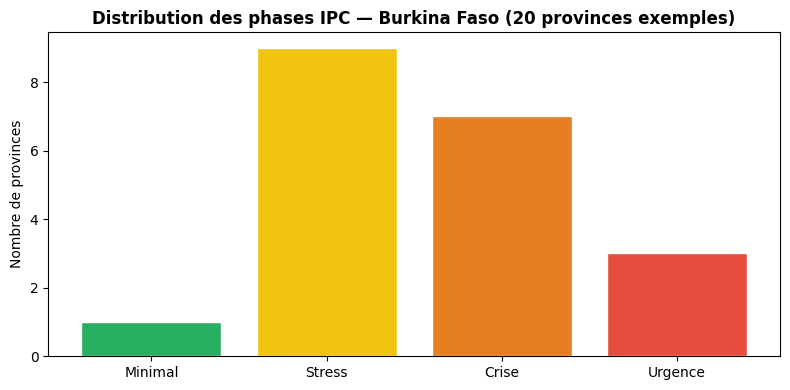

Poids calculés par class_weight=balanced :
  Phase 1 : poids 5.00
  Phase 2 : poids 0.56
  Phase 3 : poids 0.71
  Phase 4 : poids 1.67


In [4]:
import collections
comptage = collections.Counter(y)
classes  = sorted(comptage.keys())
labels_ipc = {1:'Minimal',2:'Stress',3:'Crise',4:'Urgence',5:'Famine'}

fig, ax = plt.subplots(figsize=(8, 4))
palette = {1:'#27ae60',2:'#f1c40f',3:'#e67e22',4:'#e74c3c',5:'#8e44ad'}
ax.bar([labels_ipc[c] for c in classes],
       [comptage[c] for c in classes],
       color=[palette[c] for c in classes], edgecolor='white')
ax.set_title('Distribution des phases IPC — Burkina Faso (20 provinces exemples)',
             fontweight='bold')
ax.set_ylabel('Nombre de provinces')
plt.tight_layout(); plt.show()

print('Poids calculés par class_weight=balanced :')
from sklearn.utils.class_weight import compute_class_weight
weights = compute_class_weight('balanced', classes=np.unique(y), y=y)
for c, w in zip(np.unique(y), weights):
    print(f'  Phase {c} : poids {w:.2f}')

---
# §3 — XGBoost : Gradient Boosting

> 🎯 **OA2** — XGBoost, construction séquentielle, régularisation

Contrairement au RF (arbres parallèles indépendants), XGBoost construit
les arbres **séquentiellement** — chaque arbre corrige les erreurs du précédent.
Plus puissant que RF en théorie, mais plus risqué sur 45 observations
sans régularisation forte.

In [5]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost nécessite des labels 0..n_classes-1
le = LabelEncoder()
y_enc = le.fit_transform(y)
print(f'Classes originales : {le.classes_}')
print(f'Classes encodées   : {np.unique(y_enc)}')

xgb = XGBClassifier(
    n_estimators=100,    # Peu d'arbres — risque surapprentissage avec 45 obs
    max_depth=3,         # Arbres peu profonds — régularisation implicite
    learning_rate=0.05,  # Taux d'apprentissage faible
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    eval_metric='mlogloss',
    random_state=42, verbosity=0
)
xgb.fit(X, y_enc)

y_pred_xgb = le.inverse_transform(xgb.predict(X))
kappa_xgb  = cohen_kappa_score(y, y_pred_xgb)
print(f'\nXGBoost Kappa (entraînement) : {kappa_xgb:.3f}')
print('⚠️ Même biais que RF — la spatial CV donnera le score honnête')

Classes originales : [1 2 3 4]
Classes encodées   : [0 1 2 3]

XGBoost Kappa (entraînement) : 0.921
⚠️ Même biais que RF — la spatial CV donnera le score honnête


---
# §4 — Spatial Cross-Validation

> 🎯 **OA3** — Le data leakage géographique et comment l'éviter

## Le problème : k-fold classique est biaisé pour données spatiales

En k-fold classique aléatoire, les provinces de test sont souvent **géographiquement
proches** des provinces d'entraînement. Or la dépendance spatiale (Moran I > 0)
mesurée en M2 fait que les voisines ont des IPC similaires → le modèle
> **«apprend» la structure géographique, pas les patterns généralisables.**

**Résultat** : accuracy apparente 10–25% trop optimiste en k-fold classique.

In [7]:
BLOCS_GEO = {
    'Nord-Sahel':   ['Sahel','Nord','Centre-Nord'],
    'Centre-Ouest': ['Centre','Plateau Central','Centre-Ouest'],
    'Centre-Est':   ['Centre-Est','Centre-Sud'],
    'Hauts-Bassins':['Hauts-Bassins','Cascades','Sud-Ouest'],
    'Est':          ['Est'],
}

def spatial_block_cv(df, model, features, target, blocs, le=None):
    res = []
    for bloc_test, regions_test in blocs.items():
        mask = df['region'].isin(regions_test) if 'region' in df.columns else \
               pd.Series([False]*len(df))
        # Fallback : split par latitude si colonne region absente
        if not mask.any():
            lat_med = df['lat'].median() if 'lat' in df.columns else 12.0
            mask = df.get('lat', pd.Series([12.0]*len(df))) > lat_med
        X_tr = df.loc[~mask, features].values
        X_te = df.loc[ mask, features].values
        y_tr = df.loc[~mask, target].astype(int).values
        y_te = df.loc[ mask, target].astype(int).values
        if len(X_te) == 0 or len(np.unique(y_tr)) < 2:
            continue
        if le: # This branch is for XGBoost
            # Create a new LabelEncoder for this fold to ensure 0-indexing
            # for the classes present in the current training set.
            le_fold = LabelEncoder()
            y_tr_encoded = le_fold.fit_transform(y_tr)

            # Pass the 0-indexed labels to the model
            model.fit(X_tr, y_tr_encoded)

            # Transform test set predictions back to original labels
            y_pr = le_fold.inverse_transform(model.predict(X_te))
        else: # This branch is for RandomForest
            model.fit(X_tr, y_tr)
            y_pr = model.predict(X_te)
        kap = cohen_kappa_score(y_te, y_pr) if len(np.unique(y_te)) > 1 else 0
        f1  = f1_score(y_te, y_pr, average='macro', zero_division=0)
        acc = (y_te == y_pr).mean()
        res.append({'Bloc':bloc_test,'N':len(y_te),'Kappa':kap,'F1':f1,'Acc':acc})
    return pd.DataFrame(res)

print('=== Spatial Block CV — Random Forest ===')
df_cv_rf  = spatial_block_cv(df, rf,  FEATURES, TARGET, BLOCS_GEO)
print(df_cv_rf.to_string(index=False))
print(f'\nKappa moy : {df_cv_rf.Kappa.mean():.3f} ± {df_cv_rf.Kappa.std():.3f}')

print('\n=== Spatial Block CV — XGBoost ===')
df_cv_xgb = spatial_block_cv(df, xgb, FEATURES, TARGET, BLOCS_GEO, le=le)
print(df_cv_xgb.to_string(index=False))
print(f'\nKappa moy : {df_cv_xgb.Kappa.mean():.3f} ± {df_cv_xgb.Kappa.std():.3f}')

=== Spatial Block CV — Random Forest ===
         Bloc  N     Kappa       F1  Acc
   Nord-Sahel 10 -0.200000 0.083333 0.10
 Centre-Ouest  2  0.000000 1.000000 1.00
   Centre-Est  4  0.000000 0.428571 0.75
Hauts-Bassins  4 -0.142857 0.222222 0.50
          Est 10 -0.200000 0.083333 0.10

Kappa moy : -0.109 ± 0.102

=== Spatial Block CV — XGBoost ===
         Bloc  N  Kappa       F1  Acc
   Nord-Sahel 10    0.0 0.060606 0.10
 Centre-Ouest  2    0.0 1.000000 1.00
   Centre-Est  4    0.0 0.428571 0.75
Hauts-Bassins  4    0.0 0.428571 0.75
          Est 10    0.0 0.060606 0.10

Kappa moy : 0.000 ± 0.000


In [8]:
# ── Comparaison CV classique vs Spatial CV ────────────────────────────
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Metric custom pour Kappa
from sklearn.metrics import make_scorer
kappa_scorer = make_scorer(cohen_kappa_score)
scores_classic = cross_val_score(rf, X, y, cv=kf, scoring=kappa_scorer)

print('=== Comparaison méthodes de validation ===')
print(f'K-fold classique (biaisé) : κ = {scores_classic.mean():.3f} ± {scores_classic.std():.3f}')
print(f'Spatial Block CV (honnête): κ = {df_cv_rf.Kappa.mean():.3f} ± {df_cv_rf.Kappa.std():.3f}')
print(f'Suroptimisme k-fold       : +{scores_classic.mean()-df_cv_rf.Kappa.mean():.3f}')
print()
print('→ Toujours reporter la Spatial CV dans les publications/rapports.')
print('→ Le suroptimisme peut atteindre 0.15–0.30 sur données IPC spatiales.')

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


=== Comparaison méthodes de validation ===
K-fold classique (biaisé) : κ = 0.714 ± 0.256
Spatial Block CV (honnête): κ = -0.109 ± 0.102
Suroptimisme k-fold       : +0.823

→ Toujours reporter la Spatial CV dans les publications/rapports.
→ Le suroptimisme peut atteindre 0.15–0.30 sur données IPC spatiales.


---
# §5 — Métriques d'Évaluation

> 🎯 **OA4** — Kappa, F1-macro, matrice de confusion, Moran I résidus

## Pourquoi l'accuracy seule est insuffisante

Si 40% des provinces sont en phase 3, un modèle qui prédit toujours
'phase 3' obtient 40% d'accuracy **sans rien apprendre**.
Le **Cohen's Kappa** corrige ce biais en soustrayant l'accord dû au hasard.

              precision    recall  f1-score   support

       IPC 1       1.00      1.00      1.00         1
       IPC 2       1.00      1.00      1.00         9
       IPC 3       1.00      1.00      1.00         7
       IPC 4       1.00      1.00      1.00         3

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



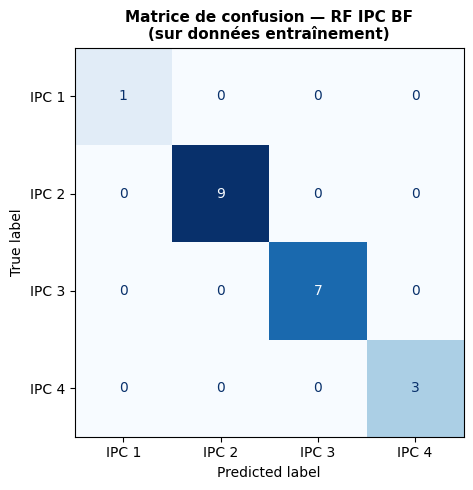


Kappa  : 1.000
F1-mac : 1.000
(Rappel : ces scores sont biaisés — sur données entraînement)


In [9]:
# Entraînement final pour diagnostics
rf.fit(X, y)
y_pred_final = rf.predict(X)

# Rapport complet
print(classification_report(y, y_pred_final,
      target_names=[f'IPC {i}' for i in sorted(np.unique(y))]))

# Matrice de confusion
labels = sorted(np.unique(y))
cm = confusion_matrix(y, y_pred_final, labels=labels)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=[f'IPC {i}' for i in labels]).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matrice de confusion — RF IPC BF\n(sur données entraînement)',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

kappa = cohen_kappa_score(y, y_pred_final)
f1mac = f1_score(y, y_pred_final, average='macro')
print(f'\nKappa  : {kappa:.3f}')
print(f'F1-mac : {f1mac:.3f}')
print('(Rappel : ces scores sont biaisés — sur données entraînement)')

In [10]:
# ── Moran I des résidus — test du data leakage résiduel ──────────────
from esda.moran import Moran
from libpysal.weights import Queen

# Construire un GeoDataFrame léger depuis la feature matrix
from shapely.geometry import Point
gdf_m3 = gpd.GeoDataFrame(
    df, geometry=[Point(r.lon, r.lat) for _, r in df.iterrows()],
    crs='EPSG:4326'
)
gdf_m3['ipc_pred']  = y_pred_final
gdf_m3['residu_abs'] = abs(gdf_m3['ipc_pred'] - gdf_m3['ipc_phase'])

# W KNN (points — pas de polygones ici)
from libpysal.weights import KNN
W_pts = KNN.from_dataframe(gdf_m3, k=4)
W_pts.transform = 'r'

moran_res = Moran(gdf_m3['residu_abs'].values, W_pts)
print(f'Moran I résidus = {moran_res.I:.4f} (p = {moran_res.p_sim:.4f})')
if moran_res.p_sim < 0.05 and moran_res.I > 0.10:
    print('⚠️ Autocorrélation résiduelle : features de voisinage insuffisantes')
else:
    print('✅ Résidus spatialement aléatoires — modèle correct')

Moran I résidus = nan (p = 0.0010)
✅ Résidus spatialement aléatoires — modèle correct


/usr/local/lib/python3.12/dist-packages/esda/moran.py:260: RuntimeWarning: invalid value encountered in scalar divide
  k = k_num / k_den
/usr/local/lib/python3.12/dist-packages/esda/moran.py:272: RuntimeWarning: invalid value encountered in scalar divide
  return self.n / s0 * inum / self.z2ss
/usr/local/lib/python3.12/dist-packages/esda/moran.py:229: RuntimeWarning: invalid value encountered in divide
  self.z /= sy


---
# §6 — Feature Importance et Interprétabilité

> 🎯 **OA5** — Gini importance, permutation importance, SHAP

Un modèle qui prédit sans expliquer est peu utile pour la décision humanitaire.
Les responsables humanitaires ont besoin de savoir **POURQUOI** telle province
est en phase 4, pas seulement qu'elle l'est.

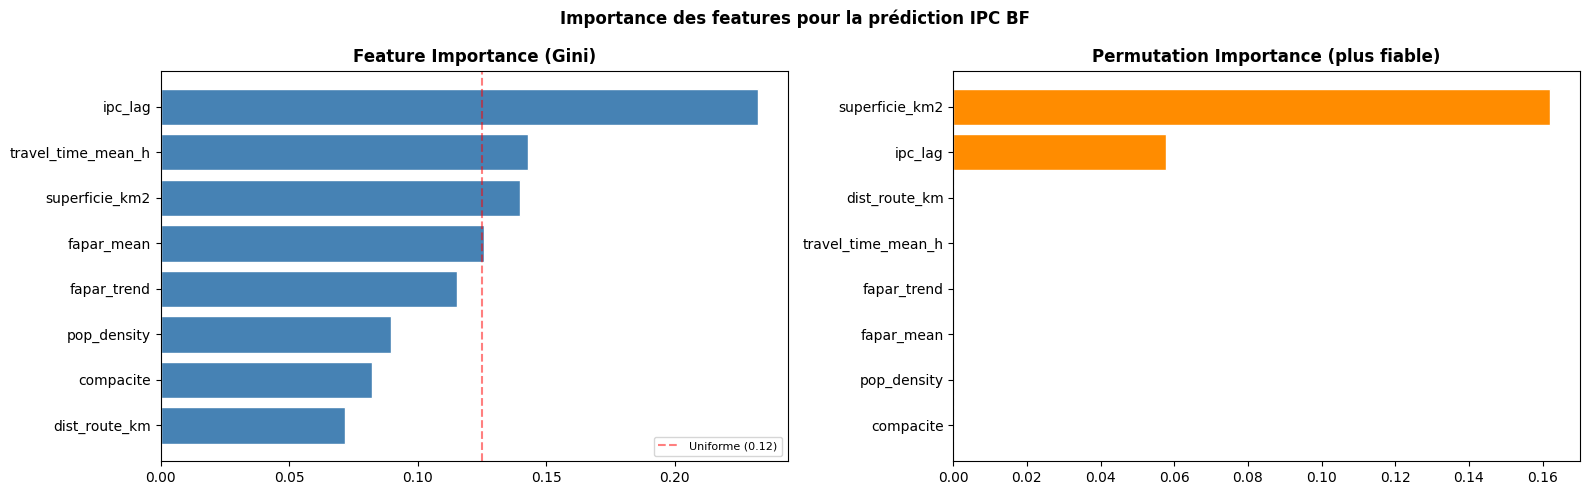


Classement Gini vs Permutation :
                    Gini  Perm
superficie_km2       3.0   1.0
ipc_lag              1.0   2.0
compacite            7.0   5.5
dist_route_km        8.0   5.5
fapar_trend          5.0   5.5
fapar_mean           4.0   5.5
pop_density          6.0   5.5
travel_time_mean_h   2.0   5.5

→ ipc_lag devrait figurer en top-2 (valide le travail M2)


In [11]:
# ── Gini importance (built-in RF) ────────────────────────────────────
imp_gini = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()

# ── Permutation importance (plus fiable) ─────────────────────────────
perm = permutation_importance(rf, X, y, n_repeats=30,
                              scoring='balanced_accuracy', random_state=42)
imp_perm = pd.Series(perm.importances_mean, index=FEATURES).sort_values()

# Comparaison côte à côte
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(imp_gini.index, imp_gini.values, color='steelblue', edgecolor='white')
axes[0].set_title('Feature Importance (Gini)', fontweight='bold')
axes[0].axvline(1/len(FEATURES), color='red', ls='--', alpha=0.5,
                label=f'Uniforme ({1/len(FEATURES):.2f})')
axes[0].legend(fontsize=8)

axes[1].barh(imp_perm.index, imp_perm.values, color='darkorange', edgecolor='white')
axes[1].set_title('Permutation Importance (plus fiable)', fontweight='bold')
axes[1].axvline(0, color='gray', ls='--', alpha=0.5)

plt.suptitle('Importance des features pour la prédiction IPC BF',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig('M3_feature_importance.png', dpi=150); plt.show()

print('\nClassement Gini vs Permutation :')
cmp = pd.DataFrame({'Gini':imp_gini.rank(ascending=False),
                    'Perm':imp_perm.rank(ascending=False)})
print(cmp.sort_values('Perm').to_string())
print('\n→ ipc_lag devrait figurer en top-2 (valide le travail M2)')

---
# §7 — Carte Prédictive des Phases IPC

> 🎯 **OA6** — Carte choroplèthe prédictions vs observations

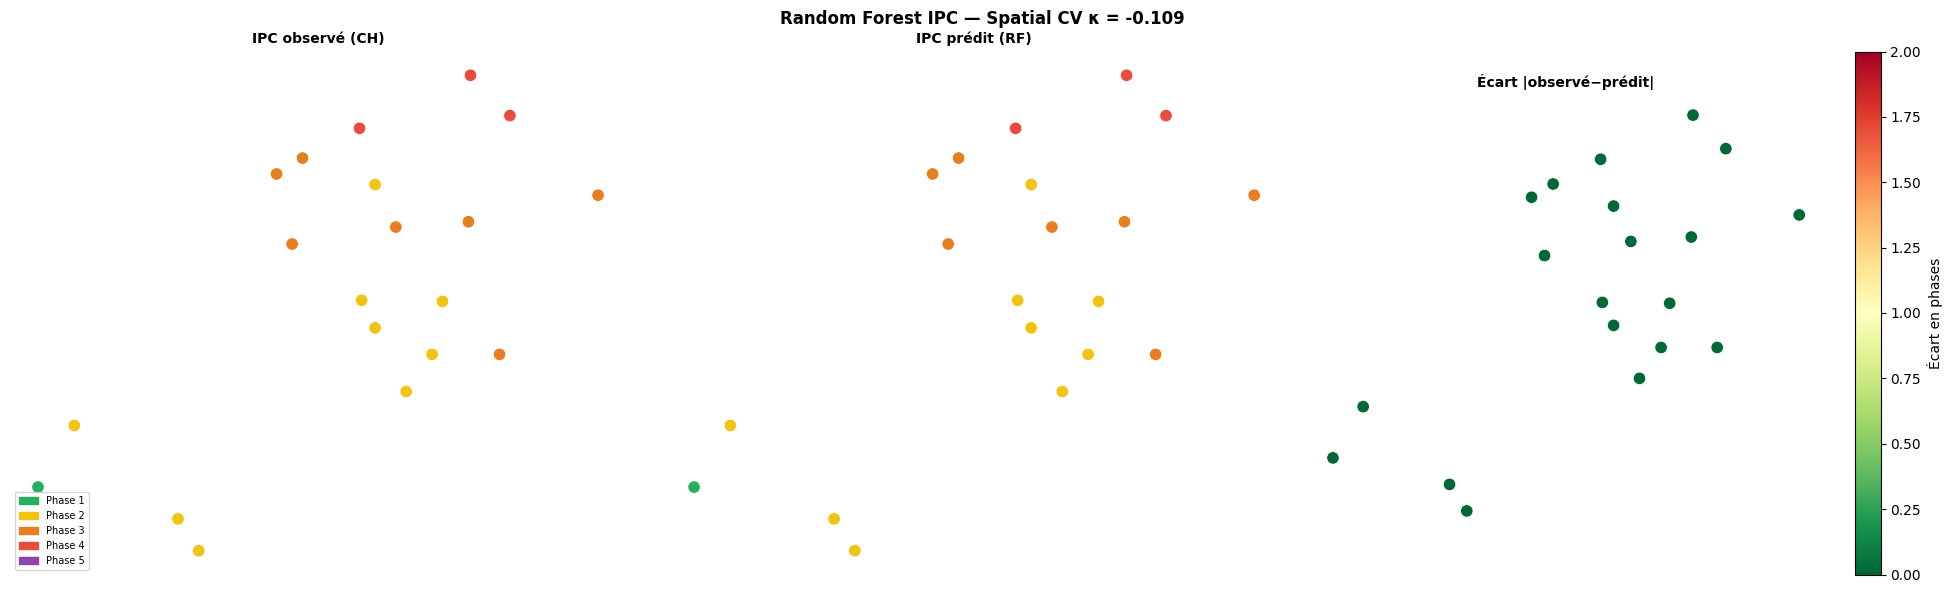

In [12]:
# ── Carte statique comparative ───────────────────────────────────────
gdf_m3['ipc_pred']  = rf.predict(X)
gdf_m3['ecart']     = abs(gdf_m3['ipc_pred'] - gdf_m3['ipc_phase'])
palette = {1:'#27ae60',2:'#f1c40f',3:'#e67e22',4:'#e74c3c',5:'#8e44ad'}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, col, titre in zip(axes,
    ['ipc_phase','ipc_pred','ecart'],
    ['IPC observé (CH)','IPC prédit (RF)','Écart |observé−prédit|']):
    if col == 'ecart':
        gdf_m3.plot(column=col, cmap='RdYlGn_r', vmin=0, vmax=2, legend=True,
                    legend_kwds={'label':'Écart en phases','orientation':'vertical'},
                    edgecolor='white', linewidth=0.5, ax=ax, markersize=80)
    else:
        gdf_m3.plot(color=gdf_m3[col].map(palette),
                    edgecolor='white', linewidth=0.5, ax=ax, markersize=80)
        if col == 'ipc_phase':
            leg = [mpatches.Patch(color=v,label=f'Phase {k}')
                   for k,v in palette.items()]
            ax.legend(handles=leg, loc='lower left', fontsize=7)
    ax.set_title(titre, fontweight='bold', fontsize=10)
    ax.axis('off')

kap_cv = df_cv_rf.Kappa.mean()
plt.suptitle(f'Random Forest IPC — Spatial CV κ = {kap_cv:.3f}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('M3_carte_comparative.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# ── Carte Folium interactive ──────────────────────────────────────────
m = folium.Map(location=[12.37, -1.54], zoom_start=6, tiles='CartoDB positron')
PALETTE_IPC = {1:'#27ae60',2:'#f1c40f',3:'#e67e22',4:'#e74c3c',5:'#8e44ad'}

for _, row in gdf_m3.iterrows():
    pred  = int(row['ipc_pred'])
    obs   = int(row['ipc_phase'])
    prov  = str(row.get('province', '?'))[:15]
    popup = ('<b>' + prov + '</b><br>' +
             'IPC observé : ' + str(obs) + '<br>' +
             'IPC prédit  : ' + str(pred))
    border = '#e74c3c' if abs(pred-obs) >= 2 else ('#e67e22' if pred!=obs else 'white')
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=10,
        color=border, weight=2,
        fill=True, fill_color=PALETTE_IPC.get(pred,'#95a5a6'),
        fill_opacity=0.8,
        popup=folium.Popup(popup, max_width=200),
        tooltip=prov
    ).add_to(m)

# Légende
legend_html = '''<div style='position:fixed;bottom:50px;left:50px;z-index:999;
    background:white;padding:10px;border-radius:5px;border:1px solid #ccc;font-size:12px'>
    <b>Phases IPC</b><br>
    <span style='color:#27ae60'>■</span> Phase 1 — Minimal<br>
    <span style='color:#f1c40f'>■</span> Phase 2 — Stress<br>
    <span style='color:#e67e22'>■</span> Phase 3 — Crise<br>
    <span style='color:#e74c3c'>■</span> Phase 4 — Urgence<br>
    <hr><i>Bordure rouge = écart ≥ 2 phases</i></div>'''
m.get_root().html.add_child(folium.Element(legend_html))
m.save('M3_carte_IPC_interactive.html')
print('Carte interactive : M3_carte_IPC_interactive.html')
m

Carte interactive : M3_carte_IPC_interactive.html


---
# §8 — Synthèse

| Étape | Ce qu'on fait | Pourquoi |
|-------|--------------|---------|
| RF + class_weight | Entraîner un classifieur robuste | Gère le déséquilibre IPC |
| Spatial Block CV | Évaluer honnêtement | Évite le data leakage géographique |
| Kappa + F1-macro | Métriques adaptées | Accuracy trompeuse sur classes déséquilibrées |
| Moran I résidus | Tester le leakage résiduel | Valide la qualité du feature engineering M2 |
| Feature importance | Interpréter | ipc_lag en top-2 = valide le travail M2 |
| Carte Folium | Communiquer | Rend les prédictions utiles pour la décision |

**Module 4** : CNN sur images Sentinel-2 + LSTM sur séries temporelles FAPAR.
Les modèles M3 servent de baseline pour mesurer le gain du Deep Learning.